# Logistic Regression: A First Classifier on 10 Points

### Table of contents
0. [Introduction](#0.-Introduction)
1. [A tiny dataset](#1.-A-tiny-dataset)
2. [Why linear regression can't do this](#2.-Why-linear-regression-can't-do-this)
3. [Fitting Logistic Regression](#3.-Fitting-Logistic-Regression)
4. [From probability to a label](#4.-From-probability-to-a-label)
5. [A first look at evaluation](#5.-A-first-look-at-evaluation)
6. [Summary](#6.-Summary)

## 0. Introduction

Regression predicts a number (week 3). Classification predicts a category. This notebook builds the first classifier, Logistic Regression, on 10 rows small enough to check by hand.

This is notebook 1 of 5 for the week:
1. Logistic Regression, toy data (this one)
2. Logistic Regression, full scale and evaluation
3. K-Nearest Neighbors
4. Decision Trees
5. Comparing all three, summary, exercises

## 1. A tiny dataset

Hours studied, and whether each student passed.

In [1]:
import pandas as pd

toy = pd.DataFrame({
    "hours_studied": [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    "passed":        [0,   0,   0,   0,   1,   0,   1,   1,   1,   1],
})
toy

,hours_studied,passed
0,0.5,0
1,1.0,0
2,1.5,0
3,2.0,0
4,2.5,1
5,3.0,0
6,3.5,1
7,4.0,1
8,4.5,1
9,5.0,1


More hours generally means passing, but not always: the 2.5h student passed and the 3.0h student didn't. Real data is rarely perfectly separable.

## 2. Why linear regression can't do this

The target is 0/1, not a continuous number. Fit both a linear and a logistic model:

In [2]:
from sklearn.linear_model import LinearRegression, LogisticRegression

X = toy[["hours_studied"]].values
y = toy["passed"].values

lin_model = LinearRegression().fit(X, y)
log_model = LogisticRegression().fit(X, y)

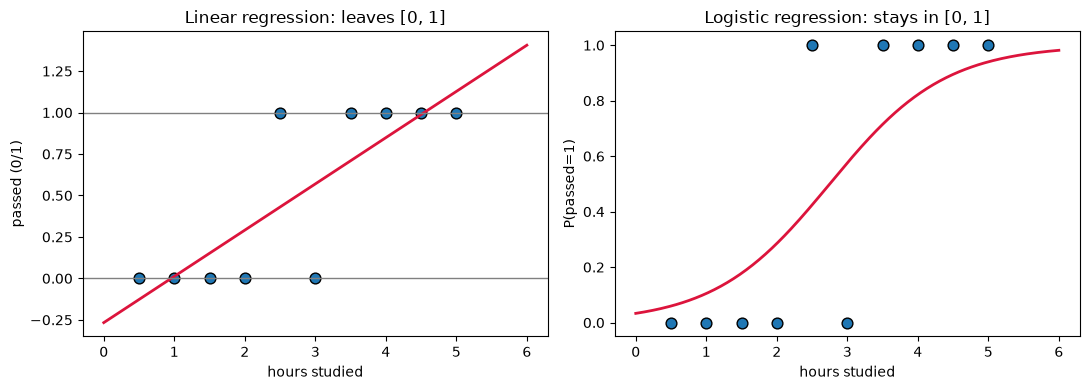

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_grid = np.linspace(0, 6, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X, y, s=60, edgecolors="k")
axes[0].plot(x_grid, lin_model.predict(x_grid), color="crimson", linewidth=2)
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].axhline(1, color="gray", linewidth=1)
axes[0].set_title("Linear regression: leaves [0, 1]")
axes[0].set_xlabel("hours studied"); axes[0].set_ylabel("passed (0/1)")

axes[1].scatter(X, y, s=60, edgecolors="k")
axes[1].plot(x_grid, log_model.predict_proba(x_grid)[:, 1], color="crimson", linewidth=2)
axes[1].set_title("Logistic regression: stays in [0, 1]")
axes[1].set_xlabel("hours studied"); axes[1].set_ylabel("P(passed=1)")
plt.tight_layout()
plt.show()

The linear fit predicts values outside `[0, 1]`, meaningless as a probability. The sigmoid-shaped logistic curve never leaves `[0, 1]`.

## 3. Fitting Logistic Regression

`log_model` is already fit above. Same `.fit()` / `.predict()` API as `LinearRegression`, plus `.predict_proba()`.

In [4]:
print(f"Coefficient (w): {log_model.coef_[0][0]:.3f}")
print(f"Intercept (b):   {log_model.intercept_[0]:.3f}")

Coefficient (w): 1.224
Intercept (b):   -3.366


In [5]:
print("P(passed=1) for each student:")
print(log_model.predict_proba(X)[:, 1].round(3))

P(passed=1) for each student:
[0.06  0.105 0.178 0.285 0.424 0.576 0.715 0.822 0.895 0.94 ]


A positive coefficient means more hours pushes the probability of passing up. Internally: `z = w*x + b`, then `sigmoid(z) = 1 / (1 + e^(-z))` squeezes `z` into `[0, 1]`.

## 4. From probability to a label

`.predict()` turns a probability into a 0/1 label using a threshold, 0.5 by default.

In [6]:
predictions = log_model.predict(X)
toy_with_preds = toy.copy()
toy_with_preds["P(passed=1)"] = log_model.predict_proba(X)[:, 1].round(3)
toy_with_preds["predicted"] = predictions
toy_with_preds

,hours_studied,passed,P(passed=1),predicted
0,0.5,0,0.060,0
1,1.0,0,0.105,0
2,1.5,0,0.178,0
3,2.0,0,0.285,0
4,2.5,1,0.424,0
5,3.0,0,0.576,1
6,3.5,1,0.715,1
7,4.0,1,0.822,1
8,4.5,1,0.895,1
9,5.0,1,0.940,1


`predicted` is exactly `P(passed=1) >= 0.5`. Nothing forces 0.5; notebook 2 explores other thresholds.

## 5. A first look at evaluation

With only 10 points there's no train/test split yet, that needs real data (notebook 2). For now, compare predictions to the true labels:

In [7]:
toy_with_preds["correct"] = toy_with_preds["passed"] == toy_with_preds["predicted"]
toy_with_preds

,hours_studied,passed,P(passed=1),predicted,correct
0,0.5,0,0.060,0,True
1,1.0,0,0.105,0,True
2,1.5,0,0.178,0,True
3,2.0,0,0.285,0,True
4,2.5,1,0.424,0,False
5,3.0,0,0.576,1,False
6,3.5,1,0.715,1,True
7,4.0,1,0.822,1,True
8,4.5,1,0.895,1,True
9,5.0,1,0.940,1,True


Count the four possible outcomes by hand (positive class = passed = 1):

In [8]:
TP = int(((toy["passed"] == 1) & (predictions == 1)).sum())
TN = int(((toy["passed"] == 0) & (predictions == 0)).sum())
FP = int(((toy["passed"] == 0) & (predictions == 1)).sum())
FN = int(((toy["passed"] == 1) & (predictions == 0)).sum())

print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")

TP=4  TN=4  FP=1  FN=1


In [9]:
print(f"Accuracy  = (TP+TN)/10  = {(TP + TN) / 10:.2f}")
print(f"Precision = TP/(TP+FP)  = {TP / (TP + FP):.2f}")
print(f"Recall    = TP/(TP+FN)  = {TP / (TP + FN):.2f}")

Accuracy  = (TP+TN)/10  = 0.80
Precision = TP/(TP+FP)  = 0.80
Recall    = TP/(TP+FN)  = 0.80


That's the entire idea behind accuracy, precision, and recall. `scikit-learn` computes the same numbers instantly, at any scale:

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("accuracy_score: ", accuracy_score(toy["passed"], predictions))
print("precision_score:", precision_score(toy["passed"], predictions))
print("recall_score:   ", recall_score(toy["passed"], predictions))

accuracy_score:  0.8
precision_score: 0.8
recall_score:    0.8


## 6. Summary

- Classification predicts a category. The useful underlying output is a probability.
- Logistic Regression feeds `z = w*x + b` through sigmoid to keep that probability in `[0, 1]`.
- A threshold (default 0.5) turns the probability into a label.
- Accuracy, precision, and recall are just counts over predicted vs. true labels.

Notebook 2 takes this exact model to a real, 569-sample, 30-feature dataset, with a train/test split and the full evaluation toolkit.